In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# I defined the functions at the top of the notebook this time around. I don't know if I like it more or less.
# I also don't know the convention for jupyter.

In [35]:
def hierarchical_clustering(X,n_clusters=1):   
    from sklearn.metrics import pairwise_distances
    
     #dataset size, number of features
    m,n = X.shape
    
    # cluster distance matrix
    dist = pairwise_distances(X)
    np.fill_diagonal(dist, np.inf)
    
    # Make each point its own cluster of one
    k = m 
    clusters = np.arange(k)

    # hierarchical clustering iteration'
    while k>n_clusters:  
        
        # find closest clusters
        i, j = np.unravel_index(np.argmin(dist),(k,k))
        i,j = np.sort([i,j]) # reorder the pair (i,j) so that  j>i
        
        # merge clusters
        clusters[clusters==j]=i

        # rename clusters
        clusters[clusters>j] -= 1
        
        # recompute distance from the new cluster i to the remaining clusters'
        dist[i] = np.minimum(dist[i],dist[j]) # 
        dist[:,i] = dist[i] # distance_clusters matrix is symmetric
        dist[i,i]= np.inf # set the distance from cluster i to itself to infinity
            
        # remove row j and column j from distance_clusters matrix
        dist = np.delete(dist,j,0) # remove row j
        dist = np.delete(dist,j,1) # remove column j
        
    
        # reduce number of clusters
        k = k-1

    return clusters

In [4]:
def kmeans(X,k,max_iterations=1000):
    from sklearn.metrics import pairwise_distances
    # initialize iteration counter
    it = 0
    repeat = True
    
    # number of datapoints
    m = X.shape[0] 
    
    # initialization
    means = X[np.random.choice(m,k,replace=False)] 
    dist = pairwise_distances(X,means)
    clusters = np.argmin(dist, axis=1)
 
    
    while repeat and it<max_iterations:
        
        # update means; # if a cluster has no data points associated with it, replace it with a random data point
        means = np.array([np.mean(X[clusters==i], axis=0) 
                          if np.sum(clusters==i)!=0
                          else  X[np.random.randint(m)]
                          for i in range(k)])
        
        # update clusters
        dist = pairwise_distances(X,means)
        new_clusters = np.argmin(dist, axis=1)
        
        # check if the new clusters are equal to the previous clusters
        if np.sum(clusters!=new_clusters)==0: 
            repeat = False
        clusters = new_clusters
                
        it += 1 # increment iteration counter by 1
    
    return clusters, means


# define inertia for given means/clusters 

def inertia(X,means,clusters,k):
    m = len(clusters)
    return np.sum([np.sum((X[clusters==i]-means[i])**2) for i in range(k)])/m

# Problem 5: Document Clustering

Document clustering is an important application of clustering algorithms.
Document clustering algorithms can be used to automatically group search results into categories, making it easier to find relevant results.

In this problem, you'll be clustering articles published on [Daily Kos](https://www.dailykos.com/), an American political blog

The file *dailykos.csv* contains data on 3,430 news articles or blogs that have been posted on Daily Kos.
These articles were posted in 2004, leading up to the United States Presidential Election. 

In [2]:
# load the data
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Theory/master/Data/dailykos.csv'
data = pd.read_csv(url)
data

,abandon,abc,ability,abortion,absolute,abstain,abu,abuse,accept,access,...,yeah,year,yesterday,york,youll,young,youre,youve,zogby,zone
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3425,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3426,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3427,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3428,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Each of the features in the dataset is a word that has appeared in at least 50 different articles (1,545 words in total).  For each document, the feature values are the number of times that word appeared in the document.

In [3]:
list_of_words = np.array(data.columns)
list(list_of_words)

['abandon',
 'abc',
 'ability',
 'abortion',
 'absolute',
 'abstain',
 'abu',
 'abuse',
 'accept',
 'access',
 'accomplish',
 'account',
 'accurate',
 'accusations',
 'achieve',
 'acknowledge',
 'act',
 'action',
 'active',
 'activist',
 'actual',
 'add',
 'added',
 'addition',
 'address',
 'admin',
 'administration',
 'admit',
 'advance',
 'advantage',
 'advertise',
 'advised',
 'affair',
 'affect',
 'affiliate',
 'afghanistan',
 'afraid',
 'afternoon',
 'age',
 'agencies',
 'agenda',
 'agree',
 'ahead',
 'aid',
 'aim',
 'air',
 'alaska',
 'allegation',
 'allegory',
 'allied',
 'allowed',
 'alternative',
 'altsite',
 'amazing',
 'amendment',
 'america',
 'american',
 'amount',
 'amp',
 'analysis',
 'analyst',
 'anecdotal',
 'anger',
 'angry',
 'announce',
 'annual',
 'answer',
 'apologies',
 'apparent',
 'appeal',
 'appearance',
 'applied',
 'appointed',
 'approach',
 'approval',
 'apr',
 'april',
 'arab',
 'area',
 'arent',
 'arg',
 'argue',
 'argument',
 'arizona',
 'arm',
 'armstro

## Part 1: k-means clustering

Cluster the articles using k-means, and ensure that you have a good number of clusters (using the "elbow" method, for example).

In [6]:
X = data.to_numpy().astype('float')

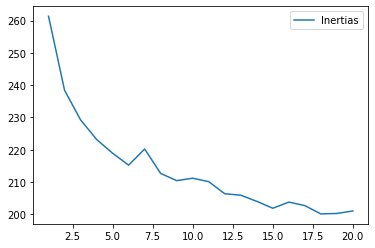

In [8]:
k_min=1
k_max=20

k_vals = np.arange(k_min,k_max+1)
    
#generate inertias array
    
inertias = np.zeros(k_max+1-k_min)
for i,k in enumerate(range(k_min,k_max+1)):
    clusters,means = kmeans(X,k)
    inertias[i] = inertia(X,means,clusters,k)
    
# plot inertia values

plt.plot(k_vals,inertias,label = 'Inertias')

plt.legend()

In [21]:
# five seems like a good number of clusters based on elbow method:
k=5
clusters,means = kmeans(X,k)

## Part 2

 Find the 10 most frequent words in each cluster.

In [34]:
for i in range(k):
    # find cluster
    
    cluster_i = X[clusters==i]
    cluster_i_sum = np.sum(cluster_i,axis=0)
    common_cluster_i = np.argsort(-cluster_i_sum)
    print('cluster ' +str(i) +' common words: ')
    print(list_of_words[common_cluster_i[0:10]])
    

cluster 0 common words: 
['november' 'vote' 'poll' 'challenge' 'bush' 'kerry' 'republican'
 'democrat' 'house' 'senate']
cluster 1 common words: 
['democrat' 'dean' 'kerry' 'state' 'republican' 'parties' 'candidate'
 'campaign' 'poll' 'race']
cluster 2 common words: 
['november' 'poll' 'challenge' 'democrat' 'vote' 'house' 'republican'
 'bush' 'senate' 'governor']
cluster 3 common words: 
['bush' 'kerry' 'democrat' 'poll' 'republican' 'elect' 'state' 'iraq'
 'war' 'time']
cluster 4 common words: 
['bush' 'kerry' 'presided' 'poll' 'iraq' 'administration' 'state' 'war'
 'democrat' 'time']


In 2004, one of the candidates for the Democratic nomination for the President of the United States was Howard Dean, John Kerry was the candidate who won the democratic nomination, and John Edwards with the running mate of John Kerry (the Vice President nominee). Given this information, which cluster best corresponds to the democratic party?

Cluster 1 has most common words 'democrat,' 'dean,' and 'kerry,' which makes it seem most likely to correspond to the democratic party.

Which k-means cluster best corresponds to the Iraq War?

Cluster 4 has the word 'Iraq' and 'war' most common of all clusters so I assume it is cluster 4.

## Part 3: Hierarchical Clustering

Now, run hierarchical clustering (this will probably take you a while. Why?)
Pick the number of clusters equal to the number of clusters you used in parts 1 and 2.

In [36]:
clusters = hierarchical_clustering(X,n_clusters=5)

****

You didn't specifically ask it, but I thought I'd see if the five clusters had different popular words this go-around:

In [37]:
for i in range(k):
    # find cluster
    
    cluster_i = X[clusters==i]
    cluster_i_sum = np.sum(cluster_i,axis=0)
    common_cluster_i = np.argsort(-cluster_i_sum)
    print('cluster ' +str(i) +' common words: ')
    print(list_of_words[common_cluster_i[0:10]])

cluster 0 common words: 
['bush' 'kerry' 'democrat' 'poll' 'november' 'republican' 'vote' 'state'
 'elect' 'house']
cluster 1 common words: 
['race' 'democrat' 'incumbency' 'poll' 'republican' 'district' 'seat'
 'percent' 'lead' 'cycle']
cluster 2 common words: 
['threat' 'iraq' 'weapon' 'presided' 'bush' 'mass' 'state' 'saddam'
 'destruction' 'regime']
cluster 3 common words: 
['parties' 'democrat' 'dnc' 'organization' 'voter' 'campaign' 'labor'
 'million' 'field' 'elect']
cluster 4 common words: 
['percent' 'bush' 'kerry' 'poll' 'november' 'vote' 'challenge' 'race'
 'presided' 'republican']


They do! cool.